In [1]:
import xarray as xr
import numpy as np
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import BoundaryNorm

import scipy
from scipy.stats import ttest_ind

/home/gabriela/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/gabriela/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
os.chdir('/mnt/storage0/jmarson/ANALYSES/MASKS')

data_grid = xr.open_dataset('ANHA4_mesh_zgr.nc')

lon = data_grid.variables['nav_lon']
lat = data_grid.variables['nav_lat'] 

mask = data.variables['tmask']
mask = mask[0, 0,1:799,1:543]

In [4]:
os.chdir('/mnt/storage0/gabriela/ANALYSES/SCRIPTS/data_from_scripts/')

vs = np.load('ANHA4-EJM010-S_TimeSeries_STRF_20071_201712.npz')
vs = vs['BarotropicStreamFunction']

vd = np.load('ANHA4-EJM012-S_TimeSeries_STRF_20071_201712.npz')
vd = vd['BarotropicStreamFunction']

mask_3d = np.broadcast_to(mask, vd.shape)

vd[mask_3d == 0] = np.nan
vs[mask_3d == 0] = np.nan



In [5]:
stat, p_val = ttest_ind(vd, vs)

In [6]:
# Average over time

avg_vd = np.nanmean(vd, axis = 0)
avg_vs = np.nanmean(vs, axis = 0)

dif = avg_vd - avg_vs

/tmp/ipykernel_218991/2319209457.py:1: RuntimeWarning: Mean of empty slice
  avg_vd = np.nanmean(vd, axis = 0)
/tmp/ipykernel_218991/2319209457.py:2: RuntimeWarning: Mean of empty slice
  avg_vs = np.nanmean(vs, axis = 0)


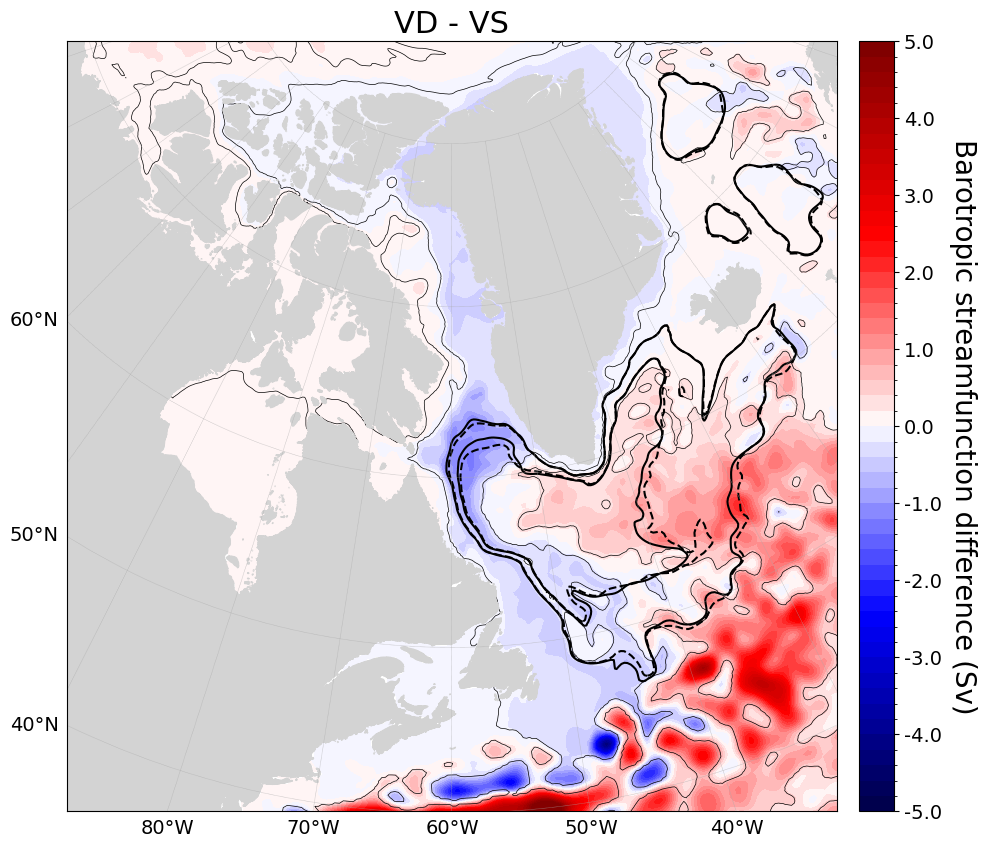

In [30]:
fig, ax = plt.subplots(figsize=(10, 10))

vmin = -5
vmax = 5
levels = 50
lv = (vmax - vmin)/levels
levels = list(np.arange(vmin, vmax+lv, lv))
cmap = plt.get_cmap('seismic')

dif[np.where(dif > vmax)] = vmax
data = dif 
title = 'VD - VS'

ax.set_title(title, fontsize=22)
m = Basemap(projection='aea', resolution='f', width=5E6, height=5E6,
            lat_0=63, lon_0=-60, ax=ax)
m.contourf(lon[1:799,1:543], lat[1:799,1:543], data, latlon=True, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap)

x, y = m(lon, lat)

m.contour(x[1:799,1:543], y[1:799,1:543], p_val,[np.nanmin(p_val), 0.01], colors = 'black', 
          linestyles = '-', linewidths = 0.5)
m.contour(x[1:799,1:543], y[1:799,1:543], avg_vd,[-10, -5], colors = 'black', linestyles = '-', linewidths = 1.5)
m.contour(x[1:799,1:543], y[1:799,1:543], avg_vs,[-10, -5], colors = 'black', 
          linestyles = 'dashed', linewidths = 1.5)


m.drawcoastlines(color='lightgray')
m.fillcontinents(color='lightgray', lake_color='lightgray')
m.drawmeridians(np.arange(0,360,10), labels=[0, 0, 0, 1], linewidth=0.4, color='darkgray', fontsize=14)
m.drawparallels(np.arange(-90,90,10), labels=[1, 0, 0, 0], linewidth=0.4, color='darkgray', fontsize=14)

# Colorbar
cax = fig.add_axes([0.92, 0.11, 0.035, 0.77])
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
    
n_ticks = 11
ticks = np.linspace(levels[0], levels[-1], n_ticks)
    
cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm,
                                  boundaries=levels,
                                  ticks=ticks,
                                  spacing='proportional')
cb.ax.tick_params(labelsize=14)
if vmax > 20:
    cb.set_ticklabels([f"{t:.0f}" for t in ticks])
else:
    cb.set_ticklabels([f"{t:.1f}" for t in ticks])
        
cb.set_label('Barotropic streamfunction difference (Sv)', rotation=270, labelpad=25, fontsize=20)


figure_title = 'BSTFdifference'
os.chdir('/mnt/storage0/gabriela/ANALYSES/FIGS/figs_paper')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()

